In [1]:
from pathlib import Path
import hashlib
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from PIL import Image, ImageFile
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18

ImageFile.LOAD_TRUNCATED_IMAGES = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)
print("GPU :", torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU")

Device : cuda
GPU : NVIDIA GeForce RTX 4060 Ti


In [2]:
def rgb_loader(path):
    with Image.open(path) as image:
        return image.convert("RGB")


project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

models_dir = project_root / "outputs" / "models"
figures_dir = project_root / "outputs" / "figures"
metrics_dir = project_root / "outputs" / "metrics"

figures_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)

data_root = Path(r"D:\datasets\waste-classifier\extracted\dataset_splits")

train_dir = data_root / "train"
test_dir = data_root / "test"

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset_for_hash = ImageFolder(
    train_dir,
    loader=rgb_loader
)

test_dataset = ImageFolder(
    test_dir,
    transform=eval_transform,
    loader=rgb_loader
)

class_names = test_dataset.classes
num_classes = len(class_names)

print("Classes :", class_names)
print("Test initial :", len(test_dataset))

Classes : ['cardboard', 'compost', 'glass', 'metal', 'paper', 'plastic', 'trash']
Test initial : 644


In [3]:
def image_hash(image_path):
    with Image.open(image_path) as image:
        image = image.convert("RGB")
        return hashlib.md5(image.tobytes()).hexdigest()


train_hashes = set(
    image_hash(path)
    for path, _ in train_dataset_for_hash.samples
)

clean_test_indices = [
    index
    for index, (path, _) in enumerate(test_dataset.samples)
    if image_hash(path) not in train_hashes
]

print("Images retirées car présentes dans train :", len(test_dataset) - len(clean_test_indices))
print("Taille du test propre :", len(clean_test_indices))

c:\Users\alid7\OneDrive\Documents\projets\deep-learning-waste-classification\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Images retirées car présentes dans train : 108
Taille du test propre : 536


In [4]:
model = resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)

resnet_path = models_dir / "resnet18_finetuned_best.pt"

checkpoint = torch.load(
    resnet_path,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Meilleure époque :", checkpoint["best_epoch"])
print("Meilleur macro F1 validation :", round(checkpoint["best_val_macro_f1"], 4))

Meilleure époque : 11
Meilleur macro F1 validation : 0.8578


In [5]:
class IndexedSubset(Dataset):
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        original_index = self.indices[position]
        image, label = self.dataset[original_index]
        return image, label, original_index


clean_indexed_dataset = IndexedSubset(
    test_dataset,
    clean_test_indices
)

clean_loader = DataLoader(
    clean_indexed_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

prediction_rows = []

with torch.no_grad():
    for images, labels, original_indices in clean_loader:
        images = images.to(device, non_blocking=True)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)

        confidences, predictions = probabilities.max(dim=1)

        for label, prediction, confidence, original_index in zip(
            labels.numpy(),
            predictions.cpu().numpy(),
            confidences.cpu().numpy(),
            original_indices.numpy()
        ):
            image_path = test_dataset.samples[original_index][0]

            prediction_rows.append({
                "path": image_path,
                "true_label": int(label),
                "predicted_label": int(prediction),
                "true_class": class_names[label],
                "predicted_class": class_names[prediction],
                "confidence": float(confidence),
                "correct": bool(label == prediction)
            })

predictions_df = pd.DataFrame(prediction_rows)

print("Nombre total d'images évaluées :", len(predictions_df))
print("Accuracy :", round(predictions_df["correct"].mean(), 4))

predictions_df.head()

Nombre total d'images évaluées : 536
Accuracy : 0.8694


,path,true_label,predicted_label,true_class,predicted_class,confidence,correct
0,D:\datasets\waste-classifier\extracted\dataset...,0,0,cardboard,cardboard,0.988001,True
1,D:\datasets\waste-classifier\extracted\dataset...,0,0,cardboard,cardboard,0.822190,True
2,D:\datasets\waste-classifier\extracted\dataset...,0,0,cardboard,cardboard,0.892652,True
3,D:\datasets\waste-classifier\extracted\dataset...,0,0,cardboard,cardboard,0.975375,True
4,D:\datasets\waste-classifier\extracted\dataset...,0,0,cardboard,cardboard,0.999902,True


In [6]:
errors_df = predictions_df[
    predictions_df["correct"] == False
].sort_values(
    by="confidence",
    ascending=False
)

print("Nombre total d'erreurs :", len(errors_df))

error_pairs_df = pd.crosstab(
    errors_df["true_class"],
    errors_df["predicted_class"]
)

print("\nConfusions les plus fréquentes :")

top_confusions = (
    errors_df
    .groupby(["true_class", "predicted_class"])
    .size()
    .sort_values(ascending=False)
    .reset_index(name="count")
)

top_confusions.head(15)

Nombre total d'erreurs : 70

Confusions les plus fréquentes :


,true_class,predicted_class,count
0,paper,cardboard,10
1,plastic,trash,7
2,trash,plastic,7
3,cardboard,paper,6
4,trash,paper,6
5,paper,trash,6
6,metal,trash,4
7,trash,compost,4
8,cardboard,plastic,3
9,cardboard,trash,3


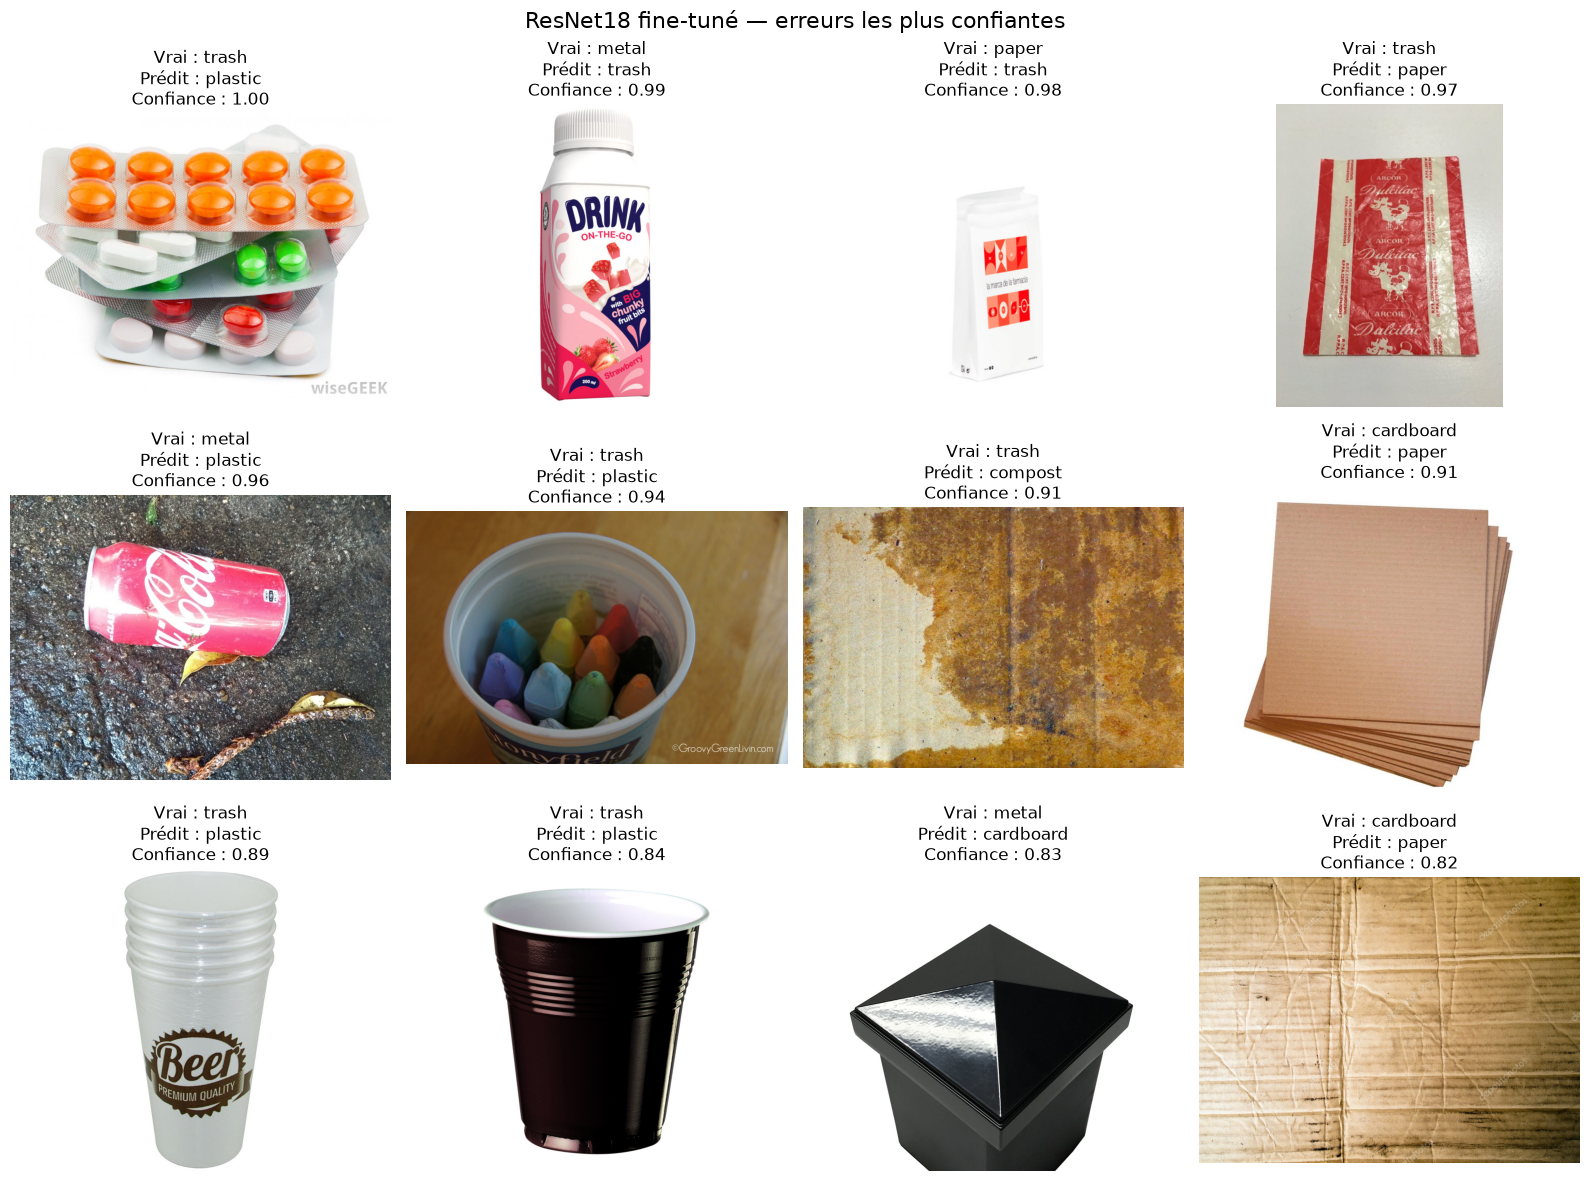

Figure sauvegardée : c:\Users\alid7\OneDrive\Documents\projets\deep-learning-waste-classification\outputs\figures\resnet18_high_confidence_errors.png


In [7]:
top_errors = errors_df.head(12).reset_index(drop=True)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for ax, (_, row) in zip(axes.flat, top_errors.iterrows()):
    with Image.open(row["path"]) as image:
        ax.imshow(image.convert("RGB"))

    ax.set_title(
        f"Vrai : {row['true_class']}\n"
        f"Prédit : {row['predicted_class']}\n"
        f"Confiance : {row['confidence']:.2f}"
    )
    ax.axis("off")

plt.suptitle(
    "ResNet18 fine-tuné — erreurs les plus confiantes",
    fontsize=16
)

plt.tight_layout()

figure_path = figures_dir / "resnet18_high_confidence_errors.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure sauvegardée :", figure_path)

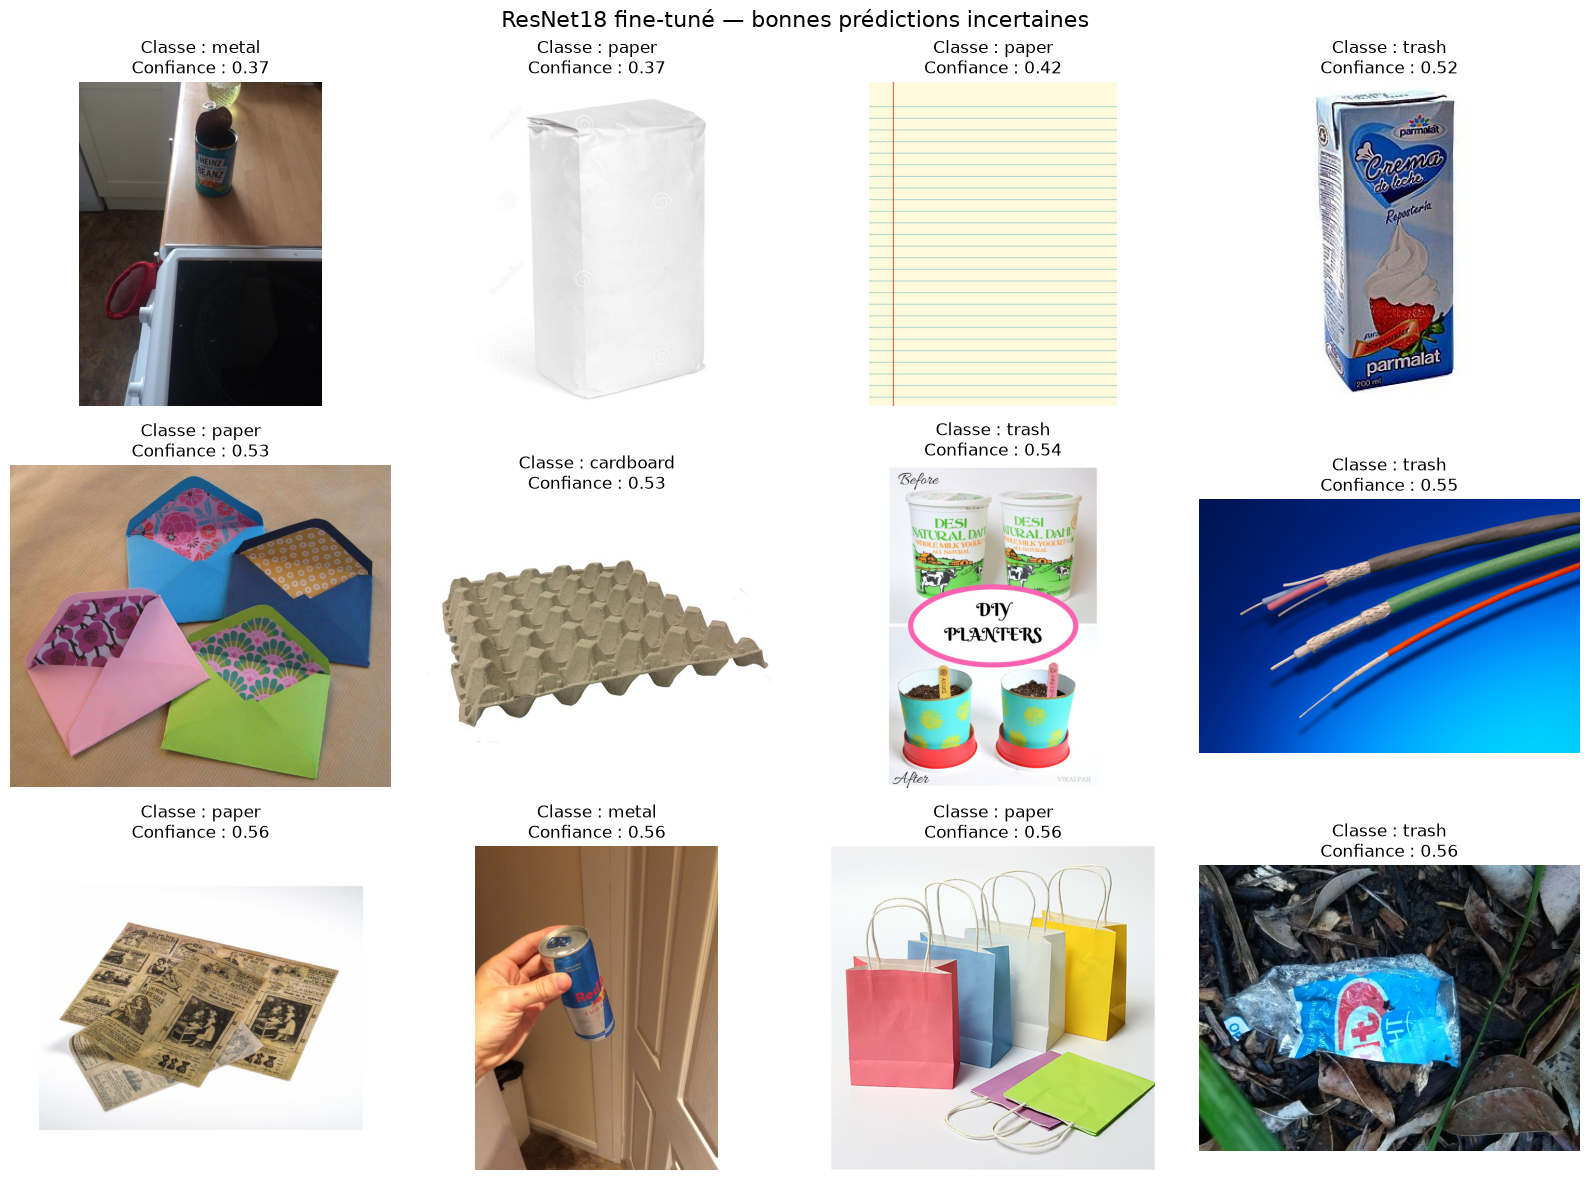

Figure sauvegardée : c:\Users\alid7\OneDrive\Documents\projets\deep-learning-waste-classification\outputs\figures\resnet18_uncertain_correct_predictions.png


In [8]:
uncertain_correct_df = predictions_df[
    predictions_df["correct"] == True
].sort_values(
    by="confidence",
    ascending=True
).head(12).reset_index(drop=True)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for ax, (_, row) in zip(axes.flat, uncertain_correct_df.iterrows()):
    with Image.open(row["path"]) as image:
        ax.imshow(image.convert("RGB"))

    ax.set_title(
        f"Classe : {row['true_class']}\n"
        f"Confiance : {row['confidence']:.2f}"
    )
    ax.axis("off")

plt.suptitle(
    "ResNet18 fine-tuné — bonnes prédictions incertaines",
    fontsize=16
)

plt.tight_layout()

figure_path = figures_dir / "resnet18_uncertain_correct_predictions.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure sauvegardée :", figure_path)

In [9]:
predictions_df.to_csv(
    metrics_dir / "resnet18_clean_test_predictions.csv",
    index=False
)

errors_df.to_csv(
    metrics_dir / "resnet18_clean_test_errors.csv",
    index=False
)

top_confusions.to_csv(
    metrics_dir / "resnet18_top_confusions.csv",
    index=False
)

print("Fichiers de l'analyse d'erreurs sauvegardés.")

Fichiers de l'analyse d'erreurs sauvegardés.
